# Classificazione delle Emozioni nei Tweet

Questo notebook implementa un modello di classificazione multi-classe per predire l'emozione dominante in un tweet.

## Descrizione del Task

**Obiettivo:** Costruire e addestrare un modello di Machine Learning per classificare l'emozione dominante espressa in un tweet.

**Emozioni (Classi):**

*   Rabbia (😡)
*   Gioia (😃)
*   Tristezza (😢)
*   Ottimismo (😊)

**Metrica di Valutazione:** Macro-Averaged F1-Score

## Dataset

Il dataset è composto dai seguenti file:

*   **Train_Text.txt:** Tweet in inglese con le relative etichette di emozione.
*   **Test_Text.txt:** Tweet in inglese senza etichette (da classificare).
*   **Val_Text.txt:** Tweet in inglese per la validazione.
*   **Val_Labels.txt:** Etichette di emozione corrispondenti a Val_Text.txt.
*   **Mapping.txt:** Mappatura tra etichette numeriche e categorie di emozione.
*   **Example_Prediction_Submission.csv:** Un esempio del formato del file di sottomissione.

## 1. Installazioni dei moduli Python

In [150]:
!pip install pandas numpy torch transformers sentence-transformers scikit-learn emoji emot

## 2. Importazione dei moduli

In [151]:
import pandas as pd
import numpy as np
import torch
from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, AutoConfig, get_linear_schedule_with_warmup
from sentence_transformers import SentenceTransformer
from sklearn.metrics import f1_score 
from sklearn.metrics.pairwise import cosine_similarity
from torch import nn
import emoji
from emot import emot
import re
from collections import defaultdict
import json
import matplotlib.pyplot as plt
from tqdm import tqdm
import time
import random
import math
from sklearn.model_selection import ParameterGrid
import copy

seed_value = 42

random.seed(seed_value)
np.random.seed(seed_value)
torch.manual_seed(seed_value)
torch.cuda.manual_seed_all(seed_value) # Se stai usando la GPU
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Controlla se la GPU è disponibile
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 3. Data Loading e Preprocessing

### 3.1. Helper Functions

Definizione delle helper functions per caricare il dataset dai file:

In [152]:
def read_lines(filepath):
    # Legge le linee da un file saltanto le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [line.strip() for line in f.readlines() if line.strip()]

def read_labels(filepath):
    # Legge le etichette intere da un file saltando le righe vuote
    with open(filepath, 'r', encoding='utf-8') as f:
        return [int(line.strip()) for line in f.readlines() if line.strip()]

def load_abbreviations(file_path="/kaggle/input/emotion/abbreviations.json"):
    with open(file_path, "r", encoding="utf-8") as file:
      abbreviations = json.load(file)
    lowercase_abbreviations = {key.lower(): value for key, value in abbreviations.items()}
    return lowercase_abbreviations

### 3.2. Data Loading

Caricamento dei dati dai file txt forniti:

In [153]:
# File paths
train_text_path = "/kaggle/input/emotion/train_text.txt"
train_labels_path = "/kaggle/input/emotion/train_labels.txt"
val_text_path = "/kaggle/input/emotion/val_text.txt"
val_labels_path = "/kaggle/input/emotion/val_labels.txt"
test_text_path = "/kaggle/input/emotion/test_text.txt"
mapping_path = "/kaggle/input/emotion/mapping.txt"

# Caricamento training set
train_texts = read_lines(train_text_path)
train_labels = read_labels(train_labels_path)

# Caricamento validation set e test set
val_texts = read_lines(val_text_path)
val_labels = read_labels(val_labels_path)
test_texts = read_lines(test_text_path)

# mapping
mapping = pd.read_csv(mapping_path, header=None, index_col=0, sep="\t")[1].to_dict()
label_to_num = {v: k for k, v in mapping.items()}

abbreviations = load_abbreviations()

print("Dati caricati con successo")
print(f"Numero di esempi di train: {len(train_texts)})")
print(f"Numero di esempi di validazione: {len(val_texts)}")
print(f"Numero di esempi di test: {len(test_texts)}")
print(f"Emotion Mapping: {mapping}")

Dati caricati con successo
Numero di esempi di train: 3257)
Numero di esempi di validazione: 374
Numero di esempi di test: 1421
Emotion Mapping: {0: 'anger', 1: 'joy', 2: 'optimism', 3: 'sadness'}


### 3.3. Data Analysis e Preprocessing

#### 3.3.1 Distribuzione delle classi

Stampiamo alcuni esempi dei tweet, per capire meglio come vengono realizzati.


In [154]:
print("Tweet di esempio (train):")
for i in range(3):
    print(f"{i+1}. {train_texts[i]} (Label: {mapping[train_labels[i]]})")

print("\nTweet di esempio (validation):")
for i in range(3):
    print(f"{i+1}. {val_texts[i]} (Label: {mapping[val_labels[i]]})")

Tweet di esempio (train):
1. “Worry is a down payment on a problem you may never have'.  Joyce Meyer.  #motivation #leadership #worry (Label: optimism)
2. My roommate: it's okay that we can't spell because we have autocorrect. #terrible #firstworldprobs (Label: anger)
3. No but that's so cute. Atsu was probably shy about photos before but cherry helped her out uwu (Label: joy)

Tweet di esempio (validation):
1. @user @user Oh, hidden revenge and anger...I rememberthe time,she rebutted you. (Label: anger)
2. if not then #teamchristine bc all tana has done is provoke her by tweeting shady shit and trying to be a hard bitch begging for a fight (Label: anger)
3. Hey @user #Fields in #skibbereen give your online delivery service a horrible name. 1.5 hours late on the 1 hour delivery window. (Label: anger)


Rappresentazione della distribuzione delle classi per mostrare se il dataset sia sbilanciato:

Distribuzione delle classi nel training set:
0    1400
1     708
2     294
3     855
Name: count, dtype: int64


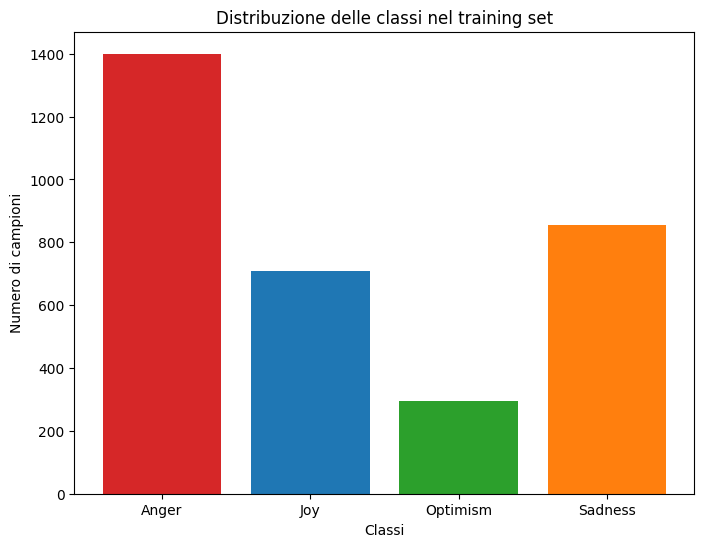

In [155]:
labels_series = pd.Series(train_labels)

# Conta il numero di campioni per ciascuna classe
class_distribution = labels_series.value_counts().sort_index()
print("Distribuzione delle classi nel training set:")
print(class_distribution)

label_names = ['Anger', 'Joy', 'Optimism', 'Sadness']
counts = [class_distribution.get(i, 0) for i in range(len(label_names))]
plt.figure(figsize=(8, 6))
plt.bar(label_names, counts, color=['tab:red', 'tab:blue', 'tab:green', 'tab:orange'])
plt.xlabel("Classi")
plt.ylabel("Numero di campioni")
plt.title("Distribuzione delle classi nel training set")
plt.show()

Per realizzare un buon modello di classificazione testuale si necessita di un dataset di addestramento che sia bilanciato. L'istogramma mostra che le classi di joy, sadness e, soprattutto, optimism sono sbilanciate rispetto alla classe anger.

#### 3.3.2 Data Augmantation sulle classi sbilanciate

Come strategia si prevede di fare data augmantation parafrasando i tweet del training set delle classi sbilanciate. L'idea è quella di generare i tweet parafrasati per mezzo di un prompt passato al modello DeepSeek. Il prompt avrà come esempio un tweet e il suo corrispettivo tweet parafrasato, entrambi scritti a mano, per ciascuna delle classi sbilanciate.

##### 3.3.2.1 Calcolo della similarità sulle classi sbilanciate

Per verificare se i tweet scritti a mano si avvicinano a quelli del dataset viene stimata la similarità media tra tutti i tweet per ciascuna delle classi (joy, optimism e sadness) per mezzo della similarità coseno.

Viene impiegato un modello più piccolo chiamato **Twitter4SSE** per ottenere gli embeddings delle frasi allo scopo di codificare la similarità semantica dei tweet. Il motivo per il quale si è deciso di impiegare questo modello è dovuto al fatto che è stato inizializzato con BERTweet (modello scelto in seguito per la classificazione) e addestrato per il Sentence-transformers.


Classe: joy (708 tweet)


Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Similarità coseno media: 0.35

Classe: optimism (294 tweet)


Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Similarità coseno media: 0.38

Classe: sadness (855 tweet)


Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Similarità coseno media: 0.37


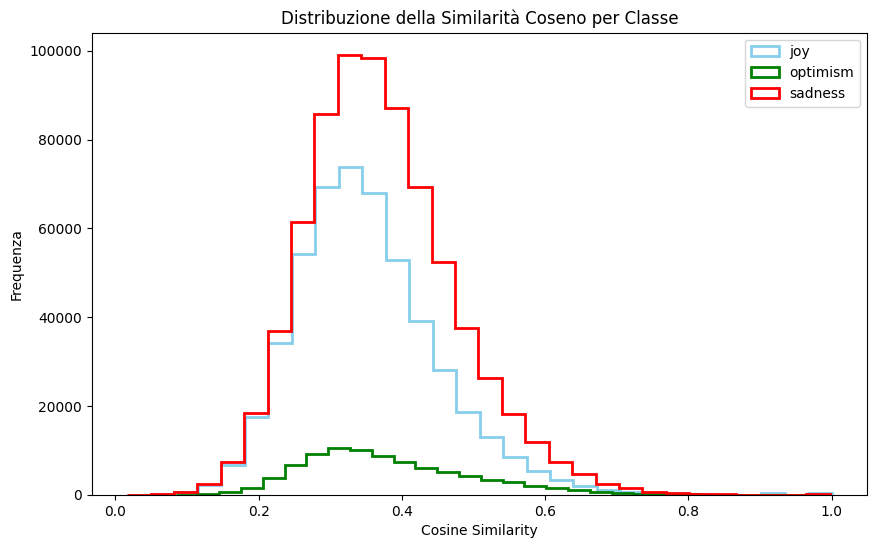

In [156]:
# Carica il modello
model_for_embeddings = SentenceTransformer("digio/Twitter4SSE")

# Mappatura delle etichette numeriche alle classi
label_to_class = {1: "joy", 2: "optimism", 3: "sadness"}

# Raggruppa i tweet per classe
tweets_by_class = {label: [] for label in label_to_class.keys()}
for text, label in zip(train_texts, train_labels):
    if label in tweets_by_class:
        tweets_by_class[label].append(text)

# Dizionario per salvare le distribuzioni di similarità per ogni classe
similarity_distributions = {}

# Calcolo della similarità coseno per ogni classe
for label, tweets in tweets_by_class.items():
    print(f"\nClasse: {label_to_class[label]} ({len(tweets)} tweet)")

    # Ottieni gli embedding dei tweet
    embeddings = model_for_embeddings.encode(tweets, convert_to_tensor=True)

    # Calcola la matrice di similarità coseno
    similarity_matrix = cosine_similarity(embeddings.cpu().numpy())

    # Imposta la diagonale a NaN per non considerare la similarità di un tweet con sé stesso
    np.fill_diagonal(similarity_matrix, np.nan)

    # Estrai i valori non NaN
    similarities = similarity_matrix.flatten()
    similarities = similarities[~np.isnan(similarities)]

    # Calcola la media della similarità per la classe
    mean_similarity = np.nanmean(similarity_matrix)
    print(f"Similarità coseno media: {mean_similarity:.2f}")

    # Salva la distribuzione per il plot
    similarity_distributions[label_to_class[label]] = similarities

# Plot della distribuzione della similarità coseno per ciascuna classe
plt.figure(figsize=(10, 6))
colors = {"joy": "skyblue", "optimism": "green", "sadness": "red"}

for emotion, similarities in similarity_distributions.items():
    plt.hist(similarities, bins=30, histtype="step", linewidth=2, label=emotion, color=colors.get(emotion, "black"))

plt.xlabel("Cosine Similarity")
plt.ylabel("Frequenza")
plt.title("Distribuzione della Similarità Coseno per Classe")
plt.legend()
plt.show()

##### 3.3.2.2 Calcolo della similarità per i tweet scritti a mano

Sono stati scritti a mano tre tweet per ciascuno delle tre classi sbilanciate. I tweet su cui si misura la similarità sono contenuti all'interno del dizionario `tweet_dict`. Per ogni tweet contenuto nel dizionario viene calcolata la similarità media con la classe corrispondente di appartenenza. Il tweet a cui viene associata la similarità più elevata, per ciascuna classe, viene scelto per essere inserito all'interno del prompt.

Anche qui viene impiegato, allo stesso modo, il modello **Twitter4SSE**. Si può notare dal risultato che la similarità media ottenuta si avvicina a quella media dei tweet del training set.

In [157]:
def compute_tweet_similarity(tweet_dict, tweets_by_class, model=model_for_embeddings):

    # Mappatura al contrario tra nome della classe e numero etichetta
    class_to_label = {v: k for k, v in label_to_class.items()}

    # Calcola gli embedding
    dataset_embeddings_by_class = {
        label : model.encode(tweets, convert_to_tensor=True)
        for label, tweets in tweets_by_class.items()
    }

    # Calcolo la media della similarità per ogni tweet del dizionario
    for emotion, tweets in tweet_dict.items():
        label = class_to_label[emotion] # Trova l'etichetta numerica corrispondente

        # Calcolo degli embedding dei tweet scritti a mano
        dict_embeddings = model.encode(tweets, convert_to_tensor=True)

        # Ottiene gli embedding dei tweet nel dataset della stessa classe
        dataset_embeddings = dataset_embeddings_by_class[label]

        # Similarità coseno
        similarity_matrix = cosine_similarity(dict_embeddings.cpu().numpy(), dataset_embeddings.cpu().numpy())

        # Calcola la media della similarità per ciascun tweet scritto a mano del dizionario
        mean_similarities = np.mean(similarity_matrix, axis=1)

        print(f"\nClasse: {emotion}")
        for tweet, mean_sim in zip(tweets, mean_similarities):
            print(f"- '{tweet}' -> Similarità media: {mean_sim:.2f}")

# Tweet scritti a mano per le classi sbilanciate
tweet_dict = {
    "joy" : ["Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳", "Nothing better than waking up to sunshine and a day full of possibilities! ☀️", "Lazy Sundays with a cup of tea and a good book = perfection."],
    "optimism" : ["“Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation", "Every challenge is just an opportunity to grow stronger. Believe in yourself!", "The rain always stops eventually. Just hold on a little longer. 🌈☔"],
    "sadness" : ["Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today.", "Can’t believe my favorite café closed down. So many good memories there. 💔", "Missing old friends and old times. Life moves so fast, sometimes too fast."]
}

compute_tweet_similarity(tweet_dict, tweets_by_class)

Batches:   0%|          | 0/23 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/27 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Classe: joy
- 'Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳' -> Similarità media: 0.36
- 'Nothing better than waking up to sunshine and a day full of possibilities! ☀️' -> Similarità media: 0.36
- 'Lazy Sundays with a cup of tea and a good book = perfection.' -> Similarità media: 0.32


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Classe: optimism
- '“Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation' -> Similarità media: 0.44
- 'Every challenge is just an opportunity to grow stronger. Believe in yourself!' -> Similarità media: 0.43
- 'The rain always stops eventually. Just hold on a little longer. 🌈☔' -> Similarità media: 0.41


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


Classe: sadness
- 'Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today.' -> Similarità media: 0.41
- 'Can’t believe my favorite café closed down. So many good memories there. 💔' -> Similarità media: 0.36
- 'Missing old friends and old times. Life moves so fast, sometimes too fast.' -> Similarità media: 0.40


Affinché il modello sia in grado di generare correttamente i tweet parafrasati a partire da quelli del training set, bisogna specificare un esempio di tweet parafrasato per ciascuno di quelli scritti a mano all'interno del prompt. Per verificare che i tweet parafrasati siano abbastanza simili si calcola la similarità coseno con il tweet originale corrispondente. Se la similarità è superiore a una soglia minima di `0.75` (scelta empiricamente) allora i tweet sono considerati simili.

In [158]:
# Funzione per il calcolo della similarità tra i tweet
def is_similar(original_tweet, paraphrased_tweet, model=model_for_embeddings):
  embedding_tweet = model.encode(original_tweet, convert_to_tensor=False).reshape(1, -1)
  embedding_paraphrased_tweet = model.encode(paraphrased_tweet, convert_to_tensor=False).reshape(1, -1)

  c_similarity = cosine_similarity(embedding_tweet, embedding_paraphrased_tweet)[0][0]

  if c_similarity >= 0.75:
    return True, c_similarity

  return False, c_similarity

# Lista per il confronto della similarità tra tweet e tweet parafrasati entrambi scritti a mano
tweet_and_paraphrased_tweet = [
    ("Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳", "I can't believe it! I just got surprise tickets to see my favorite band live! 🎸🎉"),
    ("“Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation", "Success isn't the end, failure isn't the worst—what truly matters is having the courage to keep going. 💪 #motivation"),
    ("Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today.", "There are days that feel overwhelming, and today is definitely one of them.")
    ]

for (tweet, paraphrased_tweet) in tweet_and_paraphrased_tweet:
    print(f"{tweet} e {paraphrased_tweet}: {is_similar(tweet, paraphrased_tweet)}")

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳 e I can't believe it! I just got surprise tickets to see my favorite band live! 🎸🎉: (True, 0.9290061)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

“Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation e Success isn't the end, failure isn't the worst—what truly matters is having the courage to keep going. 💪 #motivation: (True, 0.93776494)


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today. e There are days that feel overwhelming, and today is definitely one of them.: (True, 0.8217)


##### 3.3.2.3 Data Augmantation

Una volta selezionati i tweet di esempio, si definisce il prompt all'interno della lista `messages` la quale presenta due dizionari che contengono la struttura dei due messaggi che vengono inoltrati al modello tramite le **API** di DeepSeek:

*   **Primo Messaggio:**
    *   `role`: specifica il ruolo di system.
    *   `content`: riporta una serie di informazioni di contesto e vincoli che sono forniti al modello per descrivere il suo task di generare dei nuovi tweet parafrasando quelli del training set in maniera corretta.

*   **Secondo Messaggio:**
    * `role`: specifica il ruolo di user.
    * `content`: specifica l'elenco dei tre tweet di esempio che sono stati selezionati precedentemente con il calcolo della similarità con i corrispettivi tweet parafrasati e la propria etichetta associata. Infine, invita il modello a mantenere la struttura degli esempi forniti.

Successivamente viene eseguito il processo di generazione dei tweet parafrasati tramite `client.chat.completions.create` la quale consente di recuperare la risposta generata dal modello. Se la richiesta non va a buon fine ritenta la generazione della parafrasi.

In [ ]:
from openai import OpenAI
import time

# Inizializza il client con la chiave API di DeepSeek
client = OpenAI(api_key="sk-****", base_url="https://api.deepseek.com")

def paraphrase_tweet(label, tweet, temperature=0.7):
    # Prompt con gli esempi
    messages = [
        {
            "role": "system", 
            "content": (
                "You are an AI assistant specialized in paraphrasing tweets while preserving their original emotion, meaning, and context. "
                "Your task is to rephrase tweets using different wording, synonyms, and sentence structures without altering the core sentiment or key details. "
                "Your response must contain only the paraphrased tweet, with no additional explanations, notes, or comments. "
                "Pay special attention to maintaining the specified emotional tone (e.g., Joy, Optimism, Sadness)."
            )
        },
        {
            "role": "user", 
            "content": f"""Below are some examples of how to transform tweets without changing their emotional tone:
                Example 1:
                Label: Joy  
                Original tweet: Just got surprise tickets to my favorite band’s concert! Best day ever! 🎶🥳 
                Paraphrased tweet: I can't believe it! I just got surprise tickets to see my favorite band live! 🎸🎉

                Example 2:
                Label: Optimism  
                Original tweet: Some days just feel extra heavy, and that's okay. Just wish it didn’t have to be today.
                Paraphrased tweet: There are days that feel overwhelming, and today is definitely one of them.

                Example 3:
                Label: Sadness  
                Original tweet: Success is not final, failure is not fatal: it is the courage to continue that counts.” – Winston Churchill 💪 #motivation
                Paraphrased tweet: Success isn't the end, failure isn't the worst—what truly matters is having the courage to keep going. 💪 #motivation

                Now, please generate a paraphrase for the tweet below while preserving its original emotion:

                Label: {label}  
                Original tweet: {tweet}  
                Paraphrased tweet:"""
        }
    ]
    while True:
        try:
            response = client.chat.completions.create(
                model="deepseek-chat",
                messages=messages,
                temperature=temperature,
                max_tokens=256, 
                top_p=0.9,
                stream=False
            )
            result = response.choices[0].message.content.strip()
            result = result.replace("\n", "\\n")  # Mantiene i "\n" inline invece di interpretarli
            if result.startswith('"') and result.endswith('"'):
                result = result[1:-1]
            
            return result
            
        except Exception as e:
            print(f" Errore nella parafrasi: {e}. Riprovo dopo una pausa.")
            time.sleep(1)

In [160]:
# Esempio di utilizzo
tweet_originale = "I'm so excited for my trip! It's going to be an unforgettable experience!"
label = "Joy"

parafrasi = paraphrase_tweet(label, tweet_originale)
_ , similarity = is_similar(tweet_originale, parafrasi)
print(parafrasi, similarity)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

I can't wait for my upcoming adventure! It’s going to be absolutely unforgettable! 🌟✈️ 0.737285


Osservando i campioni si sceglie empiricamente uno dei tre valori di temperatura selezionati. Il sottoinsieme di campioni utilizzati per la scelta della temperatura è costituito da tre campioni estratti casualmente dal training set per ciascuna classe sbilanciata. Sulla base delle parafrasi generate dal modello si arriva alla conclusione che la scelta migliore *(a parer nostro)* per inizializzare la temperatura sia zero.

Teoricamente per scegliere la temperatura migliore avremmo dovuto generare un dataset aumentato per ogni valore di temperatura e verificare quale tra queste si avvicina di più a quella del training set per ciascuna classe. Tuttavia, essendo che i tempi di generazione del dataset aumentato sono abbastanza lunghi abbiamo optato per tale strategia.

In [161]:
import random
# Seleziona le categorie di interesse (corrispondenti alle chiavi del mapping)
# In questo caso, vogliamo le categorie 1, 2 e 3
categorie_di_interesse = [1, 2, 3]

# Dizionario per salvare i campioni selezionati per ciascuna categoria
campioni_per_categoria = {}

for cat in categorie_di_interesse:
    # Trova gli indici degli esempi appartenenti alla categoria 'cat'
    indici = [i for i, label in enumerate(train_labels) if label == cat]
    
    indici_selezionati = random.sample(indici, 3)
    
    # Estrae i testi corrispondenti agli indici selezionati
    campioni = [train_texts[i] for i in indici_selezionati]
    # Usa il nome della categoria come chiave nel dizionario
    campioni_per_categoria[mapping[cat]] = campioni

# Stampa i campioni selezionati per ciascuna categoria
for cat_name, campioni in campioni_per_categoria.items():
    print(f"\nCategoria {cat_name}:")
    for sample in campioni:
        print(sample)


Categoria joy:
Am I watching #BacheloretteAU or Zoolander ?  #samvrhys
@user YUUUHH 🙄😭 plus clin ep and prevmed ugghhh hahaha
I can't wait for you to listen to my new single 'Mystery' and my new album😋. #newmusic #newsingle #newalbum #2016 #popmusic #dark

Categoria optimism:
Don't let fear hold you back from being who you want to be. Use it's power to push you towards your goals. No more fear, just action.
Leeds surely to drop the prices for that cup tie, rather than the dismal attendance last night..
@user you may be right, but since year the bad events begin with B, I'm privately hoping we've got at least C-Z to go 1st #optimism

Categoria sadness:
Ignored broken tooth for so long, now have abscess. Need dentist but #fear makes it hard for me to go..45 and still can't go to dentist
@user I think sadness is felt very strongly physically and mentally.  It feels like it takes over and it's hard to focus at work #MHChat
When you arrive at the office the day before your first ever festi

In [162]:
'''
temperatures = [0, 0.3, 0.5]

for temp in temperatures:
    print("\n========== Temperature:", temp, "==========")
    for class_name, samples in campioni_per_categoria.items():
        print("\n----- Classe:", class_name, "-----")
        for sample in samples:
            paraphrased = paraphrase_tweet(class_name, sample, temperature=temp)
            print("Tweet originale:")
            print(sample)
            print("Tweet parafrasato:")
            print(paraphrased)
            print("---------------------------")
'''

'\ntemperatures = [0, 0.3, 0.5]\n\nfor temp in temperatures:\n    print("\n========== Temperature:", temp, "==========")\n    for class_name, samples in campioni_per_categoria.items():\n        print("\n----- Classe:", class_name, "-----")\n        for sample in samples:\n            paraphrased = paraphrase_tweet(class_name, sample, temperature=temp)\n            print("Tweet originale:")\n            print(sample)\n            print("Tweet parafrasato:")\n            print(paraphrased)\n            print("---------------------------")\n'

Dopo aver selezionato il valore di temperatura più adatto, si applica l'augmentation alle classi sbilanciate aumentando, con un massimo del `50%` rispetto al numero di campioni per classe, le dimensioni del dataset. Sperimentando diverse percentuali di aumento si è osservato che la scelta migliore è raddoppiare il numero di campioni delle classi sbilanciate.

In questa sezione, si preparano i campioni del training set sui quali applicare la data augmentation. I campioni da parafrasare sono selezionati casualmente dal training set. 

In [163]:
# Augmentation con limite massimo del doppio del conteggio originale
max_count = class_distribution.max()
augmentation_rate = 0.5  # Aggiungiamo il 50% della differenza

# Calcoliamo il numero massimo di campioni che possiamo aggiungere per classe
augmentation_per_class = {}
for label, count in class_distribution.items():
    if count == max_count:
        augmentation = 0  # Si esclude la classe più numerosa
    else:
        max_allowed = count * 2  # Limite massimo per augmentation
        augmentation = round(augmentation_rate * (max_count - count))
        augmentation = min(augmentation, max_allowed - count)  # Non superiamo il doppio
    augmentation_per_class[label] = augmentation

print("\nCampioni da aggiungere per ciascuna classe:")
for label, aug_count in augmentation_per_class.items():
    print(f"Classe {label} ({label_names[label] if label < len(label_names) else label}): {aug_count}")

# Selezione dei campioni per l'augmentation
augmentation_tasks = []
for label, aug_count in augmentation_per_class.items():
    indices = [i for i, lab in enumerate(train_labels) if lab == label]
    if not indices or aug_count <= 0:
        continue
    if aug_count > len(indices):
        selected_indices = random.choices(indices, k=aug_count)
    else:
        selected_indices = random.sample(indices, aug_count)
    for idx in selected_indices:
        augmentation_tasks.append((idx, label))

print(f"\nTotale augmentation tasks da processare: {len(augmentation_tasks)}")


Campioni da aggiungere per ciascuna classe:
Classe 0 (Anger): 0
Classe 1 (Joy): 346
Classe 2 (Optimism): 294
Classe 3 (Sadness): 272

Totale augmentation tasks da processare: 912


Selezionati i campioni si avvia il processo di data augmantation effettivo andando a memorizzare il nuovo dataset aumentato in un file e le relative etichette in due file txt. Il seguente codice è già stato eseguito ma viene commentato perché è stato eseguito in precedenza a causa delle lunghe tempistiche relative alle API di DeepSeek.

In [164]:
'''
# File di output (usati per scrivere i tweet parafrasati e le label)

train_aug_text_path   = "train_text_aug.txt"
train_aug_labels_path = "train_labels_aug.txt"

with open(train_aug_text_path, "a", encoding="utf-8") as f_text, \
     open(train_aug_labels_path, "a", encoding="utf-8") as f_labels:
    
    for idx, label_int in tqdm(augmentation_tasks, desc="Paraphrasing Tweets", unit="tweet"):
        tweet = train_texts[idx]
        label_str = mapping.get(label_int, str(label_int))

        paraphrased = paraphrase_tweet(label_str, tweet,temperature=0)
        f_text.write(paraphrased + "\n")
        f_text.flush()
        f_labels.write(str(label_int) + "\n")
        f_labels.flush()
'''

'\n# File di output (usati per scrivere i tweet parafrasati e le label)\n\ntrain_aug_text_path   = "train_text_aug.txt"\ntrain_aug_labels_path = "train_labels_aug.txt"\n\nwith open(train_aug_text_path, "a", encoding="utf-8") as f_text,      open(train_aug_labels_path, "a", encoding="utf-8") as f_labels:\n    \n    for idx, label_int in tqdm(augmentation_tasks, desc="Paraphrasing Tweets", unit="tweet"):\n        tweet = train_texts[idx]\n        label_str = mapping.get(label_int, str(label_int))\n\n        paraphrased = paraphrase_tweet(label_str, tweet,temperature=0)\n        f_text.write(paraphrased + "\n")\n        f_text.flush()\n        f_labels.write(str(label_int) + "\n")\n        f_labels.flush()\n'

Distribuzione delle classi ottenute dopo il data augmantation:

In [165]:
'''
train_text_aug_path = "/kaggle/input/emotion/train_text_aug.txt"
train_labels_aug_path = "/kaggle/input/emotion/train_labels_aug.txt"

# Caricamento del dataset aumentato
train_texts_aug = read_lines(train_text_aug_path)
train_labels_aug = read_labels(train_labels_aug_path)

# Unione tra training set e training set generato
train_texts += train_texts_aug
train_labels += train_labels_aug

labels_series = pd.Series(train_labels)

# Conta il numero di campioni per ciascuna classe
class_distribution = labels_series.value_counts().sort_index()
print("Distribuzione delle classi nel training set dopo data augmantation:")
print(class_distribution)

label_names = ['Anger', 'Joy', 'Optimism', 'Sadness']
counts = [class_distribution.get(i, 0) for i in range(len(label_names))]
plt.figure(figsize=(8, 6))
plt.bar(label_names, counts, color=['tab:red', 'tab:blue', 'tab:green', 'tab:orange'])
plt.xlabel("Classi")
plt.ylabel("Numero di campioni")
plt.title("Distribuzione delle classi nel training set dopo data augmantation")
plt.show()
'''

'\ntrain_text_aug_path = "/kaggle/input/emotion/train_text_aug.txt"\ntrain_labels_aug_path = "/kaggle/input/emotion/train_labels_aug.txt"\n\n# Caricamento del dataset aumentato\ntrain_texts_aug = read_lines(train_text_aug_path)\ntrain_labels_aug = read_labels(train_labels_aug_path)\n\n# Unione tra training set e training set generato\ntrain_texts += train_texts_aug\ntrain_labels += train_labels_aug\n\nlabels_series = pd.Series(train_labels)\n\n# Conta il numero di campioni per ciascuna classe\nclass_distribution = labels_series.value_counts().sort_index()\nprint("Distribuzione delle classi nel training set dopo data augmantation:")\nprint(class_distribution)\n\nlabel_names = [\'Anger\', \'Joy\', \'Optimism\', \'Sadness\']\ncounts = [class_distribution.get(i, 0) for i in range(len(label_names))]\nplt.figure(figsize=(8, 6))\nplt.bar(label_names, counts, color=[\'tab:red\', \'tab:blue\', \'tab:green\', \'tab:orange\'])\nplt.xlabel("Classi")\nplt.ylabel("Numero di campioni")\nplt.title("Di

### Aggiunta di Nuovi Token al Vocabolario (non più inserita)

In questa sezione si contano le occorrenze degli hashtag, emoji, emoticon e abbreviazioni distinguendo tra questi elementi quali sono riconosciuti dal vocabolario del tokenizzatore e quali non sono riconosciuti.

Successivamente, viene calcolata la frequenza al 90° percentile per i token riconosciuti. Se nessun token della categoria è presente nel vocabolario, si utilizza il 95° percentile per quelli non riconosciuti.

In [166]:
'''
model_name = "vinai/bertweet-base"
#model_name = "microsoft/deberta-v3-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
vocab = tokenizer.get_vocab()
emot_processor = emot()

# Analisi hashtag e emoji - Conteggio di quelli NON presenti nel vocabolario
hashtag_counts_not_in_vocab = defaultdict(int)
textual_emoji_counts_not_in_vocab = defaultdict(int)
emoticon_counts_not_in_vocab = defaultdict(int)
abbreviation_counts_not_in_vocab = defaultdict(int)

# Conteggio di quelli presenti nel vocabolario per calcolare la media
hashtag_counts_in_vocab = defaultdict(int)
textual_emoji_counts_in_vocab = defaultdict(int)
emoticon_counts_in_vocab = defaultdict(int)
abbreviation_counts_in_vocab = defaultdict(int)

hashtag_pattern = re.compile(r'#(\w+)')
word_pattern = re.compile(r'\b\w+\b')

for text in train_texts:
    # Analisi hashtag
    hashtags = hashtag_pattern.findall(text)
    for ht in hashtags:
        full_ht = f"#{ht}"
        if full_ht not in vocab:
            hashtag_counts_not_in_vocab[full_ht] += 1
        else:
            hashtag_counts_in_vocab[full_ht] += 1

    # Analisi emoji testuali
    demojized = emoji.demojize(text)
    for match in re.finditer(r':(\w+):', demojized):
        textual_emoji = match.group(0)
        if textual_emoji not in vocab:
            textual_emoji_counts_not_in_vocab[textual_emoji] += 1
        else:
            textual_emoji_counts_in_vocab[textual_emoji] += 1

    # Analisi emoticon
    emoticon_result = emot_processor.emoticons(text)
    if emoticon_result['flag']:
        for emoticon in emoticon_result['value']:
            if emoticon not in vocab:
                emoticon_counts_not_in_vocab[emoticon] += 1
            else:
                emoticon_counts_in_vocab[emoticon] += 1

    # Analisi abbreviazioni nel vocabolario
    words = word_pattern.findall(text.lower())
    for word in words:
        if word in abbreviations:
            if word not in vocab:
                abbreviation_counts_not_in_vocab[word] += 1
            else:
                abbreviation_counts_in_vocab[word] += 1

perc = 90
perc_not_in_vocab = 95

def get_percentile(in_vocab_counts, not_in_vocab_counts, perc=90, perc_not=95):
    using_in_vocab = bool(in_vocab_counts)
    value = (math.ceil(np.percentile(list(in_vocab_counts.values()), perc)) if using_in_vocab
            else math.ceil(np.percentile(list(not_in_vocab_counts.values()), perc_not)) if not_in_vocab_counts
            else 0)
    return value, perc if using_in_vocab else perc_not

percentiles = {
    'hashtags': get_percentile(hashtag_counts_in_vocab, hashtag_counts_not_in_vocab),
    'emojis': get_percentile(textual_emoji_counts_in_vocab, textual_emoji_counts_not_in_vocab),
    'emoticons': get_percentile(emoticon_counts_in_vocab, emoticon_counts_not_in_vocab),
    'abbreviations': get_percentile(abbreviation_counts_in_vocab, abbreviation_counts_not_in_vocab)
}

for k, (v, p) in percentiles.items():
    print(f"{p}th Percentile frequency of {k}: {v:.2f}")
'''

'\nmodel_name = "vinai/bertweet-base"\n#model_name = "microsoft/deberta-v3-base"\ntokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)\nvocab = tokenizer.get_vocab()\nemot_processor = emot()\n\n# Analisi hashtag e emoji - Conteggio di quelli NON presenti nel vocabolario\nhashtag_counts_not_in_vocab = defaultdict(int)\ntextual_emoji_counts_not_in_vocab = defaultdict(int)\nemoticon_counts_not_in_vocab = defaultdict(int)\nabbreviation_counts_not_in_vocab = defaultdict(int)\n\n# Conteggio di quelli presenti nel vocabolario per calcolare la media\nhashtag_counts_in_vocab = defaultdict(int)\ntextual_emoji_counts_in_vocab = defaultdict(int)\nemoticon_counts_in_vocab = defaultdict(int)\nabbreviation_counts_in_vocab = defaultdict(int)\n\nhashtag_pattern = re.compile(r\'#(\\w+)\')\nword_pattern = re.compile(r\'\x08\\w+\x08\')\n\nfor text in train_texts:\n    # Analisi hashtag\n    hashtags = hashtag_pattern.findall(text)\n    for ht in hashtags:\n        full_ht = f"#{ht}"\n    

### Rappresentazione delle frequenze degli elementi (non più inserita)

Questa sezione si concentra sulla rappresentazione grafica delle frequenze dei diversi elementi analizzati nel testo, suddivisi in presenti nel vocabolario e non presenti nel vocabolario.

* **Filtro dei Top N elementi:** 
    * Funzione `filter_top_n`: ordina in base alla loro frequenza in ordine descrescente e successivamente restituisce le etichette con la relativa frequenza.
* **Istogrammi:**
    * Le frequenze degli elementi sono rappresentati per mezzo di istogrammi, negli istogrammi di sinistra vengono proiettati gli elementi presenti nel vocabolario mentre quelli di destra vengono proiettati non presenti.
    * Ogni grafico mostra i `50` elementi più frequenti.

In [167]:
'''
# Numero massimo di elementi da visualizzare per ogni categoria
top_n = 50

# Funzione per selezionare solo i Top N elementi
def filter_top_n(data, top_n):
    if not data:
        return [], []  # Se il dizionario è vuoto, restituisce valori vuoti
    sorted_items = sorted(data.items(), key=lambda x: x[1], reverse=True)[:top_n]  # Ordina e prende i primi N
    labels, freqs = zip(*sorted_items)
    return labels, freqs

# Funzione per il doppio plot
def plot_separate(category, in_vocab, not_in_vocab, top_n):
    labels_in, freqs_in = filter_top_n(in_vocab, top_n)
    labels_not_in, freqs_not_in = filter_top_n(not_in_vocab, top_n)

    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # Plot per i token in vocabolario
    axes[0].barh(labels_in, freqs_in, color='green')
    axes[0].set_title(f"{category} - In Vocabolario (Top {top_n})")
    axes[0].set_xlabel("Frequenza")
    axes[0].invert_yaxis()  # Inverti per ordine decrescente
    axes[0].grid(axis="x", linestyle="--", alpha=0.7)

    # Plot per i token non in vocabolario
    axes[1].barh(labels_not_in, freqs_not_in, color='red')
    axes[1].set_title(f"{category} - Non in Vocabolario (Top {top_n})")
    axes[1].set_xlabel("Frequenza")
    axes[1].invert_yaxis()
    axes[1].grid(axis="x", linestyle="--", alpha=0.7)

    plt.tight_layout()
    plt.show()

# Plot per ogni categoria con Top N token
plot_separate("Hashtag", hashtag_counts_in_vocab, hashtag_counts_not_in_vocab, top_n)
plot_separate("Abbreviazioni", abbreviation_counts_in_vocab, abbreviation_counts_not_in_vocab, top_n)
plot_separate("Emoji Testuali", textual_emoji_counts_in_vocab, textual_emoji_counts_not_in_vocab, top_n)
plot_separate("Emoticon", emoticon_counts_in_vocab, emoticon_counts_not_in_vocab, top_n)
'''

'\n# Numero massimo di elementi da visualizzare per ogni categoria\ntop_n = 50\n\n# Funzione per selezionare solo i Top N elementi\ndef filter_top_n(data, top_n):\n    if not data:\n        return [], []  # Se il dizionario è vuoto, restituisce valori vuoti\n    sorted_items = sorted(data.items(), key=lambda x: x[1], reverse=True)[:top_n]  # Ordina e prende i primi N\n    labels, freqs = zip(*sorted_items)\n    return labels, freqs\n\n# Funzione per il doppio plot\ndef plot_separate(category, in_vocab, not_in_vocab, top_n):\n    labels_in, freqs_in = filter_top_n(in_vocab, top_n)\n    labels_not_in, freqs_not_in = filter_top_n(not_in_vocab, top_n)\n\n    fig, axes = plt.subplots(1, 2, figsize=(14, 6))\n\n    # Plot per i token in vocabolario\n    axes[0].barh(labels_in, freqs_in, color=\'green\')\n    axes[0].set_title(f"{category} - In Vocabolario (Top {top_n})")\n    axes[0].set_xlabel("Frequenza")\n    axes[0].invert_yaxis()  # Inverti per ordine decrescente\n    axes[0].grid(axis="

### 3.3.3 Preprocessing sui Tweet

Per il preprocessing dei tweet si sono applicate una serie di trasformazioni che rendono il testo più facilmente comprensibile per il modello.

*   **Normalizzazione del Testo:**
    *   Gli URL e le menzioni vengono sostituiti con `HTTPURL` e `@USER`,  rispettivamente, perché il tokenizzatore del modello `bertweet`, da noi impiegato, conosce i token per le menzioni e per gli URL in questo modo.
    *   I simboli speciali come `’` vengono sostituiti con `'` e i `…` sono sostituiti con `...`.

*   **Conversione delle Emoji in Testo:** Le emoji vengono convertite nei rispettivi codici come `😊` -> `:smile:`.

*   **Sostituzione delle abbreviazioni:** Le abbreviazioni vengono sostituite con la loro forma estesa, come `idk` -> `i don't know`, tramite il file JSON `abbreviations.json` che contiene un dizionario con lo slang e la sua corrispondente forma estesa.

*   **Gestione delle Contrazioni:**
    * Le contrazioni come `don't` vengono separate in due parole `do n't`.
    * Sono corrette anche le forme di contrazioni più specifiche come `ca n't` diventando `can't`.
    * Vengono corrette anche le forme per gli orari come `a . m .` con `a.m.`

*   **Gestione delle Emoticon:** Le emoticon nel testo vengono sostituite con il loro significato usando il modulo `emot`, questo analizza il testo e sostituisce ogni emoticon con una stringa che rappresenta il suo significato.

*   **Pulizia Spazi Extra:** Si rimuovono i eventuali spazi extra tra le parole.

In [168]:
model_name = "vinai/bertweet-base"
tokenizer = AutoTokenizer.from_pretrained(model_name, use_fast=False)
vocab = tokenizer.get_vocab()
emot_processor = emot()

def preprocess_tweet(tweet):
    # Normalizzazione menzioni e URL
    tweet = re.sub(r'@\w+', '@USER', tweet) 
    tweet = re.sub(r'https?://\S+|www\.\S+', 'HTTPURL', tweet) 

    # Normalizzazione di simboli speciali
    tweet = tweet.replace("’", "'").replace("…", "...")

    # converte le emoji in testo
    tweet = emoji.demojize(tweet)

    # Sostituzione abbreviazioni nel testo senza tokenizzazione (peggiora F1-score quindi esclusa)
    '''
    for abbr, full_form in abbreviations.items():
      if abbr not in vocab: # -> filtrando solo quelle non in vocab migliora
        tweet = re.sub(rf'\b{re.escape(abbr)}\b', full_form, tweet, flags=re.IGNORECASE)
    '''

    tweet = re.sub(r"(\w)(n't)(\W|$)", r"\1 \2\3", tweet, flags=re.IGNORECASE)  # "don't" → "do n't"
    tweet = re.sub(r"\b(ca|ai) n't\b", r"\1n't", tweet, flags=re.IGNORECASE)  # "ca n't" → "can't"
    tweet = re.sub(r"\b(a|p) \. m \.\b", r"\1.m.", tweet, flags=re.IGNORECASE)  # "a . m ." → "a.m."
    # Gestione contrazioni con apostrofo (es. 'm, 're)
    tweet = re.sub(r"\s'([md]|ll|re|ve|s)\b", r" '\1", tweet, flags=re.IGNORECASE)

    emoticon_result = emot_processor.emoticons(tweet)
    if emoticon_result['flag']:
        for emoticon, meaning in zip(emoticon_result['value'], emoticon_result['mean']):
          if emoticon_result['value'][0] not in vocab:
            tweet = tweet.replace(emoticon, meaning)
    
    # Pulizia spazi extra
    tweet = " ".join(tweet.split())

    return tweet

# Esempio di utilizzo
tweet_example = "I'm soooo happy!!! don't Check this out: idk https://example.com @user #BestDayEver &amp 😀 :)"
processed_tweet = preprocess_tweet(tweet_example)
print(processed_tweet)

I'm soooo happy!!! do n't Check this out: idk HTTPURL @USER #BestDayEver &amp :grinning_face: :)


## 4. Setup del Modello

### 4.1 Inizializzazione del Tokenizer

Analizziamo la distribuzione delle lunghezze dei testi tokenizzati per determinare un valore ottimale di `max_length`, il parametro che definisce la lunghezza massima delle sequenze per il modello.

*   **Calcolo della distribuzione delle lunghezze:** Per ogni testo presente nei dataset train, validation e test, viene calcolata la lunghezza della sequenza risultante dopo la tokenizzazione.

*   **Determinazione della lunghezza massima (max_length)**
    * Il valore iniziale di `max_length` è il massimo valore trovato in `token_lenghts`, ma non può superare il limite massimo del modello `model_max_len`.
    * Quindi si verifica che il valore finale di `max_length` non superi il limite del modello.

*   **Visualizzazione della distribuzione**
    * Due linee verticali indicano:
        * **Linea rossa tratteggiata:** Valore finale scelto per `max_length`.
        * **Linea arancione punteggiata:** Lunghezza massima consentita dal modello.

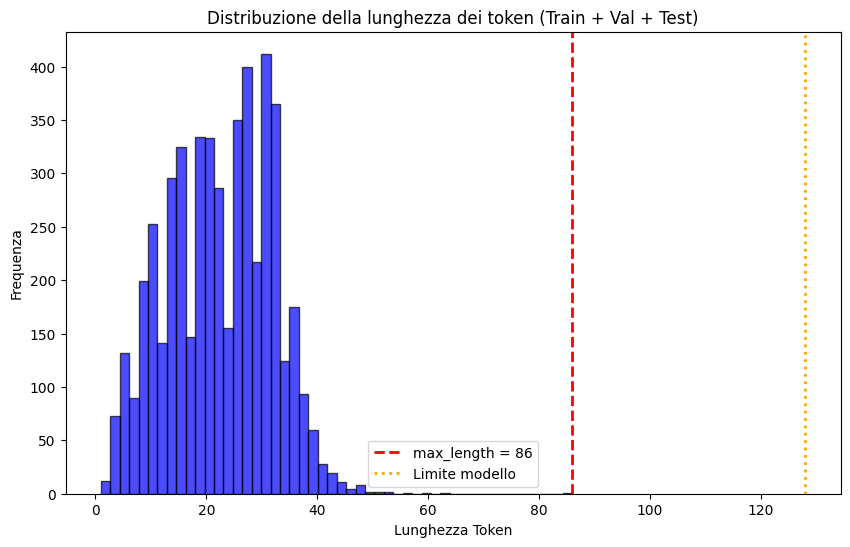

Valore scelto per max_length: 86
Massimo originale nel dataset: 86


In [169]:
# Calcoliamo la distribuzione delle lunghezze tokenizzate per tutti i set
token_lengths = [len(tokenizer.tokenize(t)) for t in train_texts + val_texts + test_texts]

model_max_len = 128
# Impostiamo max_length come il valore massimo della distribuzione
max_len = min(max(token_lengths), model_max_len)

# Visualizzazione della distribuzione
plt.figure(figsize=(10, 6))
plt.hist(token_lengths, bins=50, alpha=0.7, color='b', edgecolor='black')
plt.axvline(max_len, color='r', linestyle='dashed', linewidth=2, label=f"max_length = {max_len}")
plt.axvline(model_max_len, color='orange', linestyle='dotted', linewidth=2, label="Limite modello")
plt.title("Distribuzione della lunghezza dei token (Train + Val + Test)")
plt.xlabel("Lunghezza Token")
plt.ylabel("Frequenza")
plt.legend()
plt.show()

print(f"Valore scelto per max_length: {max_len}")
print(f"Massimo originale nel dataset: {max(token_lengths)}")

### 4.2 Classe Dataset

Questa classe rende il dataset compatibile con PyTorch, viene utilizzato per gestire i dati di input durante l'addestramento e la valutazione del modello.

1. **`__init__`**
Inizializza il dataset con:
    * `texts`: Lista dei tweet.
    * `labels`: Etichette corrispondenti.
    * `tokenizer`: Tokenizer pre-addestrato per elaborare il testo.
    * `max_len`: Lunghezza massima della sequenza tokenizzata.

2. **`__len__`**
Restituisce la cardinalità del dataset.

3. **`__getitem__`**
Recupera un elemento in base all'indice `idx`:
    * **Gestione dell'etichetta:** Viene recuperata l'etichetta corrispondente.
    * **Tokenizzazione:**
        * Il testo viene convertito in ID token con il tokenizer fornito.
        * Viene applicato il *padding* e *troncamento* per adattare ciascun token alla dimensione dell'ingresso del modello.
    * **Conversione in Tensori:**
        * Gli `input_ids` e `attention_mask` vengono restituiti in formato tensoriale.
        * L'etichetta viene convertita in tensore per essere compatibile con al funzione di perdita.

In [170]:
class TweetDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        text = preprocess_tweet(text)
        label = self.labels[idx] if self.labels is not None else -1
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors="pt"
        )
        return {
            'input_ids': encoding['input_ids'].squeeze(0),
            'attention_mask': encoding['attention_mask'].squeeze(0),
            'label': torch.tensor(label, dtype=torch.long)
        }

### 4.3 Definizione del Modello

La scelta del modello è ricaduta su BertTweet poiché rappresenta il modello più indicato essendo pre-addestrato sui tweet in lingua inglese.

1. **`__init__`** Definisce la struttura del modello.
    * **Definizione del Classificatore**
    Il classificatore aggiunto alla testa del modello è del tipo *fully connected* costituito da:
        1. Dropout (`nn.Dropout()`): aiuta a ridurre l'overfitting.
        2. Layer Finale (`nn.Linear`): restituisce i logit per la classificazione multiclasse.

2. **`forward()`** Flusso dei dati attraverso la rete
    * Elabora gli input con il modello pre-addestrato.
    * Estrae il token CLS che rappresenta l'intera frase.
    * Passa il token CLS nel classificatore, ottenendo il valore dei logit per la classificazione.

In [171]:
class EmotionClassifier(nn.Module):
    def __init__(self, num_labels, dropout, model_name, tokenizer):
        super(EmotionClassifier, self).__init__()
        self.base_model = AutoModel.from_pretrained(model_name)

        hidden_dim = self.base_model.config.hidden_size

        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, num_labels),
        )

    def forward(self, input_ids, attention_mask):
        outputs = self.base_model(input_ids=input_ids, attention_mask=attention_mask)
        last_hidden_state_cls = outputs.last_hidden_state[:, 0, :]  # CLS token
        logits = self.classifier(last_hidden_state_cls)
        return logits

### 4.4 Inizializzazione del Modello

Si inizializza il modello e si stampa la propria architettura. 

In [172]:
def print_model_summary(model):
    print("-"*89)
    print(f"| Layer Name                                              | # of Parameters | Trainable |")
    print("-"*89)
    total_num_trainable_params = 0
    for layer_name, layer_params in model.named_parameters():
        if layer_params.requires_grad:
            total_num_trainable_params += layer_params.numel()
        print(f"| {layer_name:<55} | {layer_params.numel():<15} | {str(layer_params.requires_grad):<9} |")
    print("-"*89)
    print(f"| Total # of Parameters: {total_num_trainable_params:<62} |" )
    print("-"*89)

print_model_summary(AutoModel.from_pretrained(model_name))

-----------------------------------------------------------------------------------------
| Layer Name                                              | # of Parameters | Trainable |
-----------------------------------------------------------------------------------------
| embeddings.word_embeddings.weight                       | 49152768        | True      |
| embeddings.position_embeddings.weight                   | 99840           | True      |
| embeddings.token_type_embeddings.weight                 | 768             | True      |
| embeddings.LayerNorm.weight                             | 768             | True      |
| embeddings.LayerNorm.bias                               | 768             | True      |
| encoder.layer.0.attention.self.query.weight             | 589824          | True      |
| encoder.layer.0.attention.self.query.bias               | 768             | True      |
| encoder.layer.0.attention.self.key.weight               | 589824          | True      |
| encoder.

Abbiamo provato a congelare il layer degli embedding ma si è verificato un decremento del F1-score sul validation set.

In [173]:
'''frozen_layers = ['embeddings']
for frozen_layer_name in frozen_layers:
    for layer_name, layer_params in bert.named_parameters():
        if frozen_layer_name in layer_name:
            layer_params.requires_grad = False
print_model_summary(bert)
'''

"frozen_layers = ['embeddings']\nfor frozen_layer_name in frozen_layers:\n    for layer_name, layer_params in bert.named_parameters():\n        if frozen_layer_name in layer_name:\n            layer_params.requires_grad = False\nprint_model_summary(bert)\n"

## 5. Training e Validazione

### 5.1. Classe per l'Early Stopping

Definisce la classe `EarlyStopping` per prevenire l'overfitting.

*   **`__init__`**
    * `patience`: Numero massimo di epoche consecutive senza miglioramenti prima di arrestare l'addestramento.
    * `min_delta`: Miglioramento minimo richiesto per considerare il modello migliorato.
    * `mode`: Imposta su *max* per massimizzare F1-score.
    * `counter`: Conta quante epoche consecutive non portano miglioramenti.
    * `best_score`: Inizializzato in questo caso a `-np.inf`.

*   **`__call__`**: Il metodo viene chiamato ad ogni epoca con il valore attuale della metrica.
    * Verifica il miglioramento se supera il `best_score` precedente di almeno un `min_delta`.
    * Interompe l'addestramento se si supera il valore di `patience` restituendo `True` altrimenti `False` proseguendo con il processo di addestramento.

In [174]:
class EarlyStopping:
    def __init__(self, patience=3, min_delta=0.0, mode='max'):
        self.patience = patience
        self.min_delta = min_delta
        self.mode = mode
        self.counter = 0
        self.best_score = -np.inf if mode == 'max' else np.inf

    def __call__(self, current_score):
        if self.mode == 'max':
            improvement = (current_score - self.best_score) > self.min_delta
        else:
            improvement = (self.best_score - current_score) > self.min_delta

        if improvement:
            self.best_score = current_score
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True  # Early stop
        return False

### 5.2. Funzioni per il Training e per l'Evaluation

Queste due funzioni gestiscono l'addestramento e la valutazione del modello di classificazione.

In [175]:
# Funzione di addestramento
def train_epoch(model, data_loader, loss_fn, optimizer, scheduler, device):
    model.train()
    total_loss, correct_predictions = 0, 0

    for batch in data_loader:
        # Preleva i dati dal batch
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['label'].to(device)

        optimizer.zero_grad()

        # Calcolo dei logits grezzi
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)

        # Calcolo della loss (i logits vengono passati così come sono)
        loss = loss_fn(outputs, labels)
        total_loss += loss.item()

        # Calcolo delle predizioni: per multi-classe usiamo argmax sui logits
        softmax = nn.LogSoftmax(dim=1)
        preds = softmax(outputs).argmax(dim=1)
        correct_predictions += torch.sum(preds == labels)

        # Backpropagation e aggiornamento dei pesi
        loss.backward()
        optimizer.step()
        scheduler.step()  # Aggiorna lo scheduler se necessario

    avg_loss = total_loss / len(data_loader)
    accuracy = correct_predictions.double() / len(data_loader.dataset)
    return avg_loss, accuracy

# Funzione per validazione
def eval_model(model, data_loader, loss_fn, device):
    model.eval()
    total_loss, correct_predictions = 0, 0
    predictions, targets = [], []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['label'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            loss = loss_fn(outputs, labels)
            total_loss += loss.item()

            softmax = nn.LogSoftmax(dim=1)
            preds = softmax(outputs).argmax(dim=1)
            correct_predictions += torch.sum(preds == labels)

            predictions.extend(preds.cpu().numpy())
            targets.extend(labels.cpu().numpy())

    f1 = f1_score(targets, predictions, average='macro')
    return total_loss / len(data_loader), correct_predictions.double() / len(data_loader.dataset), f1

### 5.3. Training Loop con Validazione

In questa sezione viene addestrato l'ultima parte del modello per la classificazione su una griglia di iperparametri. Questo permette di addestrare il modello su tutte le combinazioni di iperparametri valutando quale combinazione utilizzata definisce il miglior modello, la ricerca si basa tenendo traccia del F1-score più alto ottenuto sul validation set.

Tuttavia, a causa dell'inizializzazione dei pesi e dello shuffle del data loader abbiamo optato, per l'addestramento, di utilizzare la configurazione degli iperparametri che ci ha restituito i risultati migliori (senza applicare la validazione).

In [176]:
param_grid = {
    "learning_rate": [5e-5, 2e-5],
    "dropout": [0.1, 0.2],
    "batch_size": [4, 8, 16, 32]
}
# Abbiamo effettuato la validazione su una sola combinazione poichè i risultati erano affetti dall'inizializzazione dei pesi
# e dallo shuffle del data loader
param_grid = {
    "learning_rate": [2e-5],
    "dropout": [0.2],
    "batch_size": [4]
}

param_grid = ParameterGrid(param_grid)

loss_fn = nn.CrossEntropyLoss().to(device)

best_f1 = -float("inf")
best_params = None
best_metrics_history_global = None
best_model_weights_global = None

epochs = 5

num_labels = len(mapping)

train_dataset = TweetDataset(train_texts, train_labels, tokenizer, max_len)
val_dataset = TweetDataset(val_texts, val_labels, tokenizer, max_len)
test_dataset = TweetDataset(test_texts, None, tokenizer, max_len)

# Iterazione su tutte le combinazioni
for params in param_grid:
    print(f"Validazione sui parametri: {params}\n")
    best_val_f1 = -np.inf
    best_model_weights = None

    # Inizializza una lista per salvare le metriche di ogni epoca per questa combinazione
    epoch_metrics = []

    learning_rate = params["learning_rate"]
    dropout = params["dropout"]
    batch_size = params["batch_size"]

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    print("Data Loaders Pronti")
    model = EmotionClassifier(num_labels, dropout, model_name, tokenizer).to(device)
    early_stopping = EarlyStopping(patience=3, min_delta=0.005, mode='max')
    # Ottimizzatore e Scheduler
    optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=learning_rate)
    # Creiamo lo scheduler
    # Numero complessivo di passi di addestramento è [# batch] x [# epoche]
    total_steps = len(train_loader) * epochs

    # Il numero di passi di warmup è il 10% del totale dei passi di addestramento
    num_warmup_steps = total_steps // 10

    # Lo scheduler regola il learning rate in modo lineare:
    # - Parte da 0 durante il warmup (primi num_warmup_steps passi)
    # - Aumenta gradualmente fino a raggiungere il valore di learning rate
    # - Successivamente, decresce linearmente fino a 0 entro la fine dell'addestramento
    scheduler = get_linear_schedule_with_warmup(optimizer,
                                                num_warmup_steps = num_warmup_steps,
                                                num_training_steps = total_steps)

    # Inizializza la barra di progresso principale
    epochs_progress = tqdm(range(epochs), desc='Training', unit='epoche')
    for epoch in epochs_progress:
        start_time = time.time()
        epochs_progress.set_description(f"Epoca {epoch+1}")

        # Addestramento con barra di progresso
        train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, scheduler, device)

        # Validazione
        val_loss, val_acc, val_f1 = eval_model(model, val_loader, loss_fn, device)

        # Calcolo tempo impiegato
        epoch_time = time.time() - start_time

        # Aggiorna la descrizione della barra di progresso
        epochs_progress.set_postfix({
            'Train Loss': f"{train_loss:.4f}",
            'Val F1': f"{val_f1:.4f}",
            'Time': f"{epoch_time:.1f}s"
        })

        # Stampa dettagliata
        print(f"\nEpoca {epoch + 1}/{epochs}")
        print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
        print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1: {val_f1:.4f}")
        print(f"Tempo impiegato: {epoch_time:.1f} secondi")

        # Salvo le metriche dell'epoca corrente
        epoch_metrics.append({
            "epoch": epoch + 1,
            "train_loss": train_loss,
            "train_acc": train_acc,
            "val_loss": val_loss,
            "val_acc": val_acc,
            "val_f1": val_f1
        })

        # Salvataggio miglior modello
        if val_f1 > best_val_f1 + early_stopping.min_delta:
            best_val_f1 = val_f1
            best_metrics_history = epoch_metrics.copy()  
            best_model_weights = model.state_dict().copy()
            print(f"Nuovo miglior F1: {best_val_f1:.4f}")

        if early_stopping(val_f1):
            print(f"Early stopping attivato. Miglior F1: {best_val_f1:.4f}")
            break

    # Aggiorna il miglior modello globale se il modello corrente è migliore
    if best_val_f1 > best_f1:
        best_f1 = best_val_f1
        best_params = params
        best_metrics_history_global = best_metrics_history  
        best_model_weights_global = best_model_weights  
        print(f"Nuovo miglior F1 globale: {best_f1:.4f}")

print("Training Completato")
print(f"\nParametri Migliori: {best_params}")
print(f"Miglior F1 Score: {best_f1:.4f}")

torch.save(best_model_weights_global, "best_model_weights_emotion.pt")
print(f"Modello migliore salvato")

Validazione sui parametri: {'batch_size': 4, 'dropout': 0.2, 'learning_rate': 2e-05}

Data Loaders Pronti


Epoca 2:  20%|██        | 1/5 [00:53<03:32, 53.21s/epoche, Train Loss=0.9334, Val F1=0.7760, Time=53.2s]


Epoca 1/5
Train Loss: 0.9334 | Train Acc: 0.6239
Val Loss: 0.4853 | Val Acc: 0.8369 | Val F1: 0.7760
Tempo impiegato: 53.2 secondi
Nuovo miglior F1: 0.7760


Epoca 3:  40%|████      | 2/5 [01:46<02:39, 53.19s/epoche, Train Loss=0.4541, Val F1=0.8147, Time=53.2s]


Epoca 2/5
Train Loss: 0.4541 | Train Acc: 0.8422
Val Loss: 0.4473 | Val Acc: 0.8583 | Val F1: 0.8147
Tempo impiegato: 53.2 secondi
Nuovo miglior F1: 0.8147


...


Epoca 3/5
Train Loss: 0.2367 | Train Acc: 0.9278
Val Loss: 0.5044 | Val Acc: 0.8449 | Val F1: 0.7976
Tempo impiegato: 53.2 secondi


Epoca 5:  80%|████████  | 4/5 [03:32<00:53, 53.18s/epoche, Train Loss=0.1337, Val F1=0.7676, Time=53.2s]


Epoca 4/5
Train Loss: 0.1337 | Train Acc: 0.9632
Val Loss: 0.5521 | Val Acc: 0.8209 | Val F1: 0.7676
Tempo impiegato: 53.2 secondi


Epoca 5:  80%|████████  | 4/5 [04:25<01:06, 66.48s/epoche, Train Loss=0.0822, Val F1=0.7664, Time=53.2s]



Epoca 5/5
Train Loss: 0.0822 | Train Acc: 0.9828
Val Loss: 0.5656 | Val Acc: 0.8262 | Val F1: 0.7664
Tempo impiegato: 53.2 secondi
Early stopping attivato. Miglior F1: 0.8147
Nuovo miglior F1 globale: 0.8147
Training Completato

Parametri Migliori: {'batch_size': 4, 'dropout': 0.2, 'learning_rate': 2e-05}
Miglior F1 Score: 0.8147
Modello migliore salvato


Si continua ad addestrare sul modello migliore ottenuto in validazione per 10 epoche ulteriori per provare a vedere se riesce a generalizzare o overfitta:

In [177]:
model = EmotionClassifier(num_labels, best_params["dropout"], model_name, tokenizer).to(device)

# Carica i pesi salvati
best_model_path = "best_model_weights_emotion.pt"
model.load_state_dict(torch.load(best_model_path, map_location=device))

additional_epochs = 10
additional_epoch_metrics = []  # Lista per salvare le metriche delle epoche addizionali

# Riutilizzo dei dataset e ricreazione dei DataLoader con il batch size dei migliori iperparametri
train_loader = DataLoader(train_dataset, batch_size=best_params["batch_size"], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=best_params["batch_size"], shuffle=False)

# Reinizializza ottimizzatore e scheduler per le nuove epoche
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=best_params["learning_rate"])
total_steps = len(train_loader) * additional_epochs

scheduler = get_linear_schedule_with_warmup(optimizer,
                                            num_warmup_steps=0,
                                            num_training_steps=total_steps)

print("\n=== Continuazione dell'addestramento sul miglior modello per ulteriori 10 epoche ===")
epochs_progress = tqdm(range(additional_epochs), desc='Training', unit='epoch')

best_model_weights = None
for epoch in epochs_progress:
    start_time = time.time()
    epochs_progress.set_description(f"Epoch {epoch+1}")

    # Addestramento
    train_loss, train_acc = train_epoch(model, train_loader, loss_fn, optimizer, scheduler, device)

    # Validazione
    val_loss, val_acc, val_f1 = eval_model(model, val_loader, loss_fn, device)

    epoch_time = time.time() - start_time

    # Aggiorna la descrizione della barra di progresso
    epochs_progress.set_postfix({
        'Train Loss': f"{train_loss:.4f}",
        'Val F1': f"{val_f1:.4f}",
        'Time': f"{epoch_time:.1f}s"
    })

    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | Val F1:{val_f1:.4f}")

    additional_epoch_metrics.append({
        "epoch": epoch + 1,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_f1": val_f1
    })

    # Confronto con il best_f1 globale e salvataggio solo se il nuovo F1 lo supera
    if val_f1 > best_f1 + 0.005:
        best_f1 = val_f1
        best_model_weights = model.state_dict().copy()
        print(f"Nuovo miglior F1 globale: {best_f1:.4f}")

if best_model_weights is not None:
    torch.save(best_model_weights, "best_model_weights.pt")

model = EmotionClassifier(num_labels, best_params["dropout"], model_name, tokenizer).to(device)
model.load_state_dict(torch.load(best_model_path, map_location=device))
print(f"Tempo impiegato: {epoch_time:.1f}s")

<ipython-input-177-7275461bb368>:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))



=== Continuazione dell'addestramento sul miglior modello per ulteriori 10 epoche ===


Epoch 2:  10%|█         | 1/10 [00:53<07:58, 53.22s/epoch, Train Loss=0.1676, Val F1=0.7754, Time=53.2s]

Train Loss: 0.1676 | Train Acc: 0.9496
Val Loss: 0.6517 | Val Acc: 0.8342 | Val F1:0.7754


Epoch 3:  20%|██        | 2/10 [01:46<07:05, 53.18s/epoch, Train Loss=0.1177, Val F1=0.7452, Time=53.1s]

...

Train Loss: 0.0120 | Train Acc: 0.9966
Val Loss: 0.9259 | Val Acc: 0.8182 | Val F1:0.7622


Epoch 10: 100%|██████████| 10/10 [08:51<00:00, 53.14s/epoch, Train Loss=0.0071, Val F1=0.7668, Time=53.0s]


Train Loss: 0.0071 | Train Acc: 0.9991
Val Loss: 0.9400 | Val Acc: 0.8182 | Val F1:0.7668


<ipython-input-177-7275461bb368>:67: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(best_model_path, map_location=device))


Tempo impiegato: 53.0s


Rappresentazione grafica sulle metriche ottenute. 

*   **Grafico sulla sinistra:** rappresenta la differenza tra gli andamenti delle `Loss` e delle `Accuracy`.
*   **Grafico sulla destra:** rappresenta `F1-score` ottenuto in validazione.
*   **Linea verticale:** indica l'inizio dell'andamento ottenuto sul training per le 10 epoche aggiuntive.

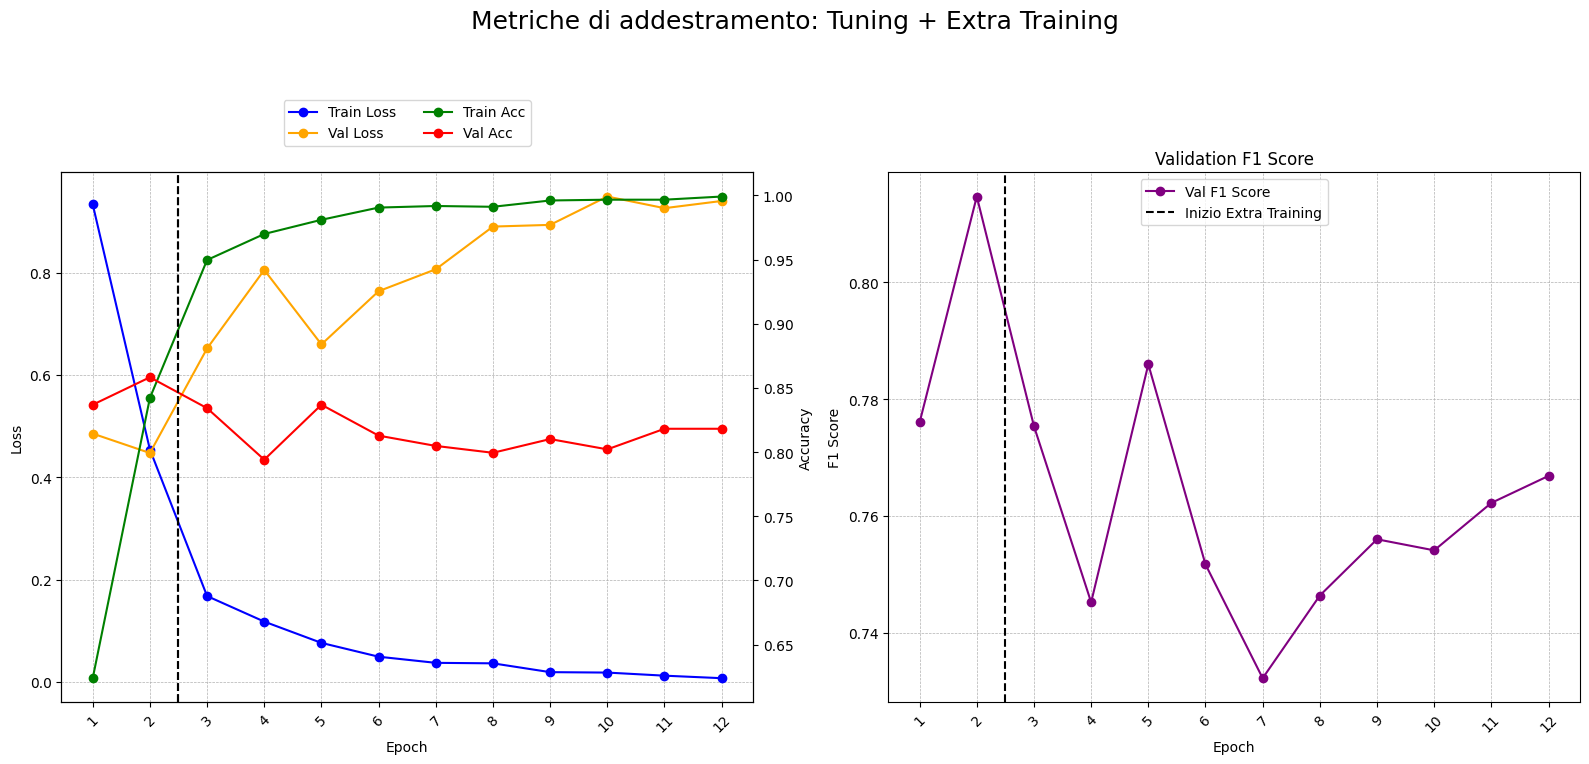

In [178]:
# Funzione per convertire un valore in float se è un tensore
def to_float(x):
    return x.cpu().item() if torch.is_tensor(x) else x

# Combiniamo le metriche della fase di tuning e quelle addizionali
all_epochs = best_metrics_history_global + additional_epoch_metrics
epochs_range = list(range(1, len(all_epochs) + 1))

# Creiamo un dizionario che contiene le metriche da plottare
metrics = {
    'train_loss': [to_float(m["train_loss"]) for m in all_epochs],
    'val_loss':   [to_float(m["val_loss"])   for m in all_epochs],
    'train_acc':  [to_float(m["train_acc"])  for m in all_epochs],
    'val_acc':    [to_float(m["val_acc"])    for m in all_epochs],
    'val_f1':     [to_float(m["val_f1"])     for m in all_epochs]
}

# Determiniamo il punto in cui inizia l'extra training
# Supponiamo che best_metrics_history_global contenga le metriche della fase di tuning
tuning_epochs = len(best_metrics_history_global)
extra_start = tuning_epochs + 0.5

# Creiamo una figura con 2 subplot affiancati
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), sharex=True)

# Subplot sinistro: Loss e Accuracy
# Plottiamo loss (train e validation) sull'asse principale
ax1.plot(epochs_range, metrics['train_loss'], label="Train Loss", marker='o', color='blue')
ax1.plot(epochs_range, metrics['val_loss'], label="Val Loss", marker='o', color='orange')
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
ax1.set_xticks(epochs_range)  # Mostriamo ogni epoca
ax1.tick_params(axis='x', rotation=45)

# Plottiamo l'accuracy su un asse secondario
ax1_acc = ax1.twinx()
ax1_acc.plot(epochs_range, metrics['train_acc'], label="Train Acc", marker='o', color='green')
ax1_acc.plot(epochs_range, metrics['val_acc'], label="Val Acc", marker='o', color='red')
ax1_acc.set_ylabel("Accuracy")

# Combiniamo le legende di entrambi gli assi
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1_acc.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2)

# Aggiungiamo la linea verticale che indica l'inizio dell'extra training
ax1.axvline(x=extra_start, color='black', linestyle='--', label="Inizio Extra Training")
ax1_acc.axvline(x=extra_start, color='black', linestyle='--')

# Subplot destro: Validation F1 Score
ax2.plot(epochs_range, metrics['val_f1'], label="Val F1 Score", marker='o', color='purple')
ax2.set_xlabel("Epoch")
ax2.set_ylabel("F1 Score")
ax2.set_title("Validation F1 Score")
ax2.grid(True, which='both', linestyle='--', linewidth=0.5)
ax2.set_xticks(epochs_range)  # Mostriamo ogni epoca
ax2.tick_params(axis='x', rotation=45)
ax2.axvline(x=extra_start, color='black', linestyle='--', label="Inizio Extra Training")
ax2.legend(loc='upper center')

# Layout finale e visualizzazione
plt.suptitle("Metriche di addestramento: Tuning + Extra Training", fontsize=18)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## 6. Prediction

### 6.1. Funzione per la predizione

Definizione di una funzione per creare le predizioni sul test set:

In [179]:
def predict_emotions(model, data_loader, device):
    model.eval()
    predictions = []
    with torch.no_grad():
        for batch in data_loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            softmax = nn.LogSoftmax(dim=1)
            preds = softmax(outputs).argmax(dim=1)
            predictions.extend(preds.cpu().numpy())
    return predictions

### 6.2. Predizioni Ottenute

Genera le predizioni per il test set:

In [180]:
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)
test_predictions = predict_emotions(model, test_loader, device)

## 7. Submission

### 7.1. Crea il Submission CSV

Crea un file CSV con le predizioni nel formato richiesto:

In [181]:
submission_df = pd.DataFrame({'label': test_predictions})
submission_df.to_csv("predictions.csv", index=False)

print("Predizioni memorizzate in predictions.csv")

Predizioni memorizzate in predictions.csv
